# Notebook 09 — Algoritmo Genético + SVM
**Desempenho Socioeconômico no ENEM (2012–2024)**

Usa um **Algoritmo Genético (AG)** para otimizar hiperparâmetros do LinearSVC em vez de
grid search exaustivo. O AG explora o espaço de busca de forma mais eficiente quando o
número de combinações é grande.

**Genes do cromossomo:**
- `gene[0]`: `log₁₀(C)` ∈ [−3, 2] → C ∈ [0.001, 100]
- `gene[1]`: `class_weight` ∈ {None, balanced} (binário)

**Avaliação de fitness:** Macro F1 num subset de 30k amostras (velocidade ~1s/eval).
Modelo final treinado no conjunto completo (300k) com os melhores parâmetros.

| Seção | Conteúdo |
|---|---|
| 0 | Setup |
| 1 | Carregamento via DuckDB |
| 2 | Pré-processamento e split |
| 3 | Algoritmo Genético |
| 4 | AG — M1 (ENEM only) |
| 5 | AG — M2 (ENEM + IDHM) |
| 6 | Modelos finais |
| 7 | Figuras |
| 8 | Persistência |

## Seção 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import duckdb

from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Dados ─────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_SAMPLE     = 500_000
DATA_DIR     = '../data/processed'
MODELS_DIR   = '../data/models'
FIGS_DIR     = DATA_DIR
PARQUET      = f'{DATA_DIR}/dataset_analitico.parquet'
os.makedirs(MODELS_DIR, exist_ok=True)

FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# ── AG ────────────────────────────────────────────────────────────────────────
GA_POP   = 25       # indivíduos por geração
GA_GENS  = 20       # gerações
GA_CXPB  = 0.70    # prob. crossover
GA_MUTPB = 0.25    # prob. mutação (por indivíduo)
GA_TOUR  = 3       # tamanho do torneio
GA_ELITE = 2       # elitismo
GA_SUB   = 30_000  # subset de treino para fitness
GA_SEED  = 42

# gene[0]: log10(C) | gene[1]: class_weight balanced (0/1)
GENE_LO = np.array([-3.0, 0.0])
GENE_HI = np.array([ 2.0, 1.0])
N_GENES = 2

print('Setup OK')
print(f'  AG: pop={GA_POP}, gens={GA_GENS}, subset={GA_SUB:,}')
print(f'  Espaço: log10(C) ∈ [{GENE_LO[0]}, {GENE_HI[0]}]  |  class_weight ∈ {{None, balanced}}')

Setup OK
  AG: pop=25, gens=20, subset=30,000
  Espaço: log10(C) ∈ [-3.0, 2.0]  |  class_weight ∈ {None, balanced}


## Seção 1 — Carregamento via DuckDB

In [2]:
con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        CASE
            WHEN FAIXA_MT IN ('<400', '400-500')    THEN 0
            WHEN FAIXA_MT IN ('500-600', '600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800', '>800')    THEN 2
        END::TINYINT AS y_mt
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra: {len(df):,} registros')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra: 139,027 registros
  Baixo (<500): 72,719 (52.3%)
  Médio (500–700): 56,457 (40.6%)
  Alto (>700): 9,851 (7.1%)


## Seção 2 — Pré-processamento e Split

In [3]:
df['tp_sexo']   = df['TP_SEXO'].map({'F':0,'0':0,'M':1,'1':1})
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'],   errors='coerce')
df['q001']      = df['Q001'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q002']      = df['Q002'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q006']      = df['Q006_HARM'].map({c:i for i,c in enumerate('ABCDE')})
df['regiao']    = df['REGIAO'].map({'Norte':0,'Nordeste':1,'Centro-Oeste':2,'Sul':3,'Sudeste':4})
df['ano']       = df['NU_ANO'].astype('float32')

def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

FEATS_BASE = ['tp_sexo','tp_cor','tp_escola','q001','q002','q006','regiao','ano']
FEATS_IDHM = [
    'idhm','idhm_educacao','idhm_renda','idhm_longevidade',
    'renda_percapita','tx_analfabetismo','tx_envelhecimento',
    'esperanca_vida','mortalidade_infantil'
]
FEATS_Q_EXT = [
    'q_ocup_pai','q_ocup_mae','q_n_pessoas','q_empregada',
    'q_carro','q_moto','q_geladeira','q_lavadora','q_tv',
    'q_computador','q_internet','q_celular','q_tipo_esc_em','q_bolsa_fam'
]
FEATS_M1 = FEATS_BASE
FEATS_M2 = FEATS_BASE + FEATS_IDHM
FEATS_M3 = FEATS_BASE + FEATS_Q_EXT
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_Q_EXT

X_m1 = df[FEATS_M1].values.astype('float32')
X_m2 = df[FEATS_M2].values.astype('float32')
X_m3 = df[FEATS_M3].values.astype('float32')
X_m4 = df[FEATS_M4].values.astype('float32')
y    = df['y_mt'].values.astype('int8')
del df; gc.collect()

# Split 60/20/20
(Xm1_tmp, Xm1_test, Xm2_tmp, Xm2_test,
 Xm3_tmp, Xm3_test, Xm4_tmp, Xm4_test,
 y_tmp, y_test) = train_test_split(
    X_m1, X_m2, X_m3, X_m4, y,
    test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
(Xm1_tr, Xm1_val, Xm2_tr, Xm2_val,
 Xm3_tr, Xm3_val, Xm4_tr, Xm4_val,
 y_tr, y_val) = train_test_split(
    Xm1_tmp, Xm2_tmp, Xm3_tmp, Xm4_tmp, y_tmp,
    test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE
)
del Xm1_tmp, Xm2_tmp, Xm3_tmp, Xm4_tmp, y_tmp; gc.collect()

# Subsets para fitness do AG
(_, Xm1_sub, _, Xm2_sub, _, Xm3_sub, _, Xm4_sub,
 _, y_sub) = train_test_split(
    Xm1_tr, Xm2_tr, Xm3_tr, Xm4_tr, y_tr,
    test_size=GA_SUB, stratify=y_tr, random_state=RANDOM_STATE
)
(_, Xm1_subval, _, Xm2_subval, _, Xm3_subval, _, Xm4_subval,
 _, y_subval) = train_test_split(
    Xm1_val, Xm2_val, Xm3_val, Xm4_val, y_val,
    test_size=10_000, stratify=y_val, random_state=RANDOM_STATE
)

print(f'Train: {len(y_tr):,} | Val: {len(y_val):,} | Test: {len(y_test):,} [SELADO]')
print(f'Subset AG — treino: {len(y_sub):,} | val: {len(y_subval):,}')
print(f'M1={len(FEATS_M1)} | M2={len(FEATS_M2)} | M3={len(FEATS_M3)} | M4={len(FEATS_M4)} features')


Train: 83,415 | Val: 27,806 | Test: 27,806 [SELADO]
Subset AG — treino: 30,000 | val: 10,000
M1=8 | M2=17 | M3=22 | M4=31 features


In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(Xm1_tr, y_tr)
yp_dummy = dummy.predict(Xm1_val)
baseline = {
    'Accuracy'   : accuracy_score(y_val, yp_dummy),
    'Macro F1'   : f1_score(y_val, yp_dummy, average='macro'),
    'Weighted F1': f1_score(y_val, yp_dummy, average='weighted'),
}
print('Baseline (majority):')
for k, v in baseline.items():
    print(f'  {k:<15s}: {v:.4f}')

Baseline (majority):
  Accuracy       : 0.5231
  Macro F1       : 0.2289
  Weighted F1    : 0.3593


## Seção 3 — Algoritmo Genético

| Operador | Estratégia |
|---|---|
| Representação | Real-valued: `[log10(C), class_weight]` |
| Seleção | Torneio (k=3) |
| Crossover | Uniforme (troca gene a gene, p=0.5 por gene) |
| Mutação gene 0 | Gaussiana σ=0.6, clampado em [−3, 2] |
| Mutação gene 1 | Flip binário |
| Elitismo | Top-2 passam direto para próxima geração |

In [5]:
def make_svm(C, balanced):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('svm',     LinearSVC(
            C=C,
            class_weight='balanced' if balanced else None,
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])


def decode(ind):
    C        = float(10 ** np.clip(ind[0], GENE_LO[0], GENE_HI[0]))
    balanced = bool(round(float(np.clip(ind[1], 0.0, 1.0))))
    return C, balanced


def fitness(ind, X_tr, X_v, y_tr, y_v):
    C, balanced = decode(ind)
    try:
        pipe = make_svm(C, balanced)
        pipe.fit(X_tr, y_tr)
        return f1_score(y_v, pipe.predict(X_v), average='macro')
    except Exception:
        return 0.0


def init_pop(rng):
    return np.column_stack([
        rng.uniform(GENE_LO[0], GENE_HI[0], GA_POP),
        rng.integers(0, 2, GA_POP).astype(float),
    ])


def tournament(pop, fits, rng):
    idx = rng.integers(0, len(pop), GA_TOUR)
    return pop[idx[np.argmax(fits[idx])]].copy()


def crossover(p1, p2, rng):
    mask = rng.random(N_GENES) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)


def mutate(ind, rng):
    ind = ind.copy()
    if rng.random() < 0.4:
        ind[0] = np.clip(ind[0] + rng.normal(0, 0.6), GENE_LO[0], GENE_HI[0])
    if rng.random() < 0.3:
        ind[1] = 1.0 - ind[1]
    return ind


def evolve(X_tr, X_v, y_tr, y_v, label=''):
    rng  = np.random.default_rng(GA_SEED)
    pop  = init_pop(rng)
    fits = np.array([fitness(ind, X_tr, X_v, y_tr, y_v) for ind in pop])

    history  = [fits.max()]
    C0, b0   = decode(pop[fits.argmax()])
    print(f'[{label}] Gen  0 — best={fits.max():.4f}  C={C0:.4f}  balanced={b0}')

    for gen in range(1, GA_GENS + 1):
        elite   = list(pop[np.argsort(fits)[-GA_ELITE:]])
        new_pop = elite[:]

        while len(new_pop) < GA_POP:
            p1, p2 = tournament(pop, fits, rng), tournament(pop, fits, rng)
            c1, c2 = crossover(p1, p2, rng) if rng.random() < GA_CXPB else (p1.copy(), p2.copy())
            if rng.random() < GA_MUTPB: c1 = mutate(c1, rng)
            if rng.random() < GA_MUTPB: c2 = mutate(c2, rng)
            new_pop.append(c1)
            if len(new_pop) < GA_POP:
                new_pop.append(c2)

        pop  = np.array(new_pop)
        fits = np.array([fitness(ind, X_tr, X_v, y_tr, y_v) for ind in pop])
        history.append(fits.max())

        C_b, b_b = decode(pop[fits.argmax()])
        print(f'[{label}] Gen {gen:2d} — best={fits.max():.4f}  '
              f'C={C_b:.4f}  balanced={b_b}  mean={fits.mean():.4f}')

    best_idx = fits.argmax()
    return pop[best_idx], fits[best_idx], history


print('Funções do AG definidas.')

Funções do AG definidas.


## Seção 4 — AG: Modelo M1 (ENEM only)

In [6]:
print('=== AG — M1 (ENEM only) ===')
t0 = time.time()
best_ind_m1, best_fit_m1, hist_m1 = evolve(Xm1_sub, Xm1_subval, y_sub, y_subval, label='M1')
best_C_m1, best_bal_m1 = decode(best_ind_m1)
print(f'\nMelhor M1: C={best_C_m1:.4f}, balanced={best_bal_m1}')
print(f'Fitness (subset): {best_fit_m1:.4f}  |  Tempo: {(time.time()-t0)/60:.1f} min')

=== AG — M1 (ENEM only) ===
[M1] Gen  0 — best=0.4709  C=7.4094  balanced=True
[M1] Gen  1 — best=0.4709  C=0.0030  balanced=True  mean=0.4511
[M1] Gen  2 — best=0.4709  C=0.0030  balanced=True  mean=0.4544
[M1] Gen  3 — best=0.4709  C=0.0026  balanced=True  mean=0.4544
[M1] Gen  4 — best=0.4710  C=0.0021  balanced=True  mean=0.4709
[M1] Gen  5 — best=0.4710  C=0.0021  balanced=True  mean=0.4643
[M1] Gen  6 — best=0.4710  C=0.0026  balanced=True  mean=0.4677
[M1] Gen  7 — best=0.4710  C=0.0021  balanced=True  mean=0.4710
[M1] Gen  8 — best=0.4710  C=0.0021  balanced=True  mean=0.4644
[M1] Gen  9 — best=0.4710  C=0.0021  balanced=True  mean=0.4644
[M1] Gen 10 — best=0.4710  C=0.0026  balanced=True  mean=0.4710
[M1] Gen 11 — best=0.4710  C=0.0026  balanced=True  mean=0.4710
[M1] Gen 12 — best=0.4710  C=0.0021  balanced=True  mean=0.4677
[M1] Gen 13 — best=0.4710  C=0.0026  balanced=True  mean=0.4710
[M1] Gen 14 — best=0.4710  C=0.0021  balanced=True  mean=0.4677
[M1] Gen 15 — best=0.4710

## Seção 5 — AG: Modelo M2 (ENEM + IDHM)

In [7]:
print('=== AG — M2 (ENEM + IDHM) ===')
t0 = time.time()
best_ind_m2, best_fit_m2, hist_m2 = evolve(Xm2_sub, Xm2_subval, y_sub, y_subval, label='M2')
best_C_m2, best_bal_m2 = decode(best_ind_m2)
print(f'\nMelhor M2: C={best_C_m2:.4f}, balanced={best_bal_m2}')
print(f'Fitness (subset): {best_fit_m2:.4f}  |  Tempo: {(time.time()-t0)/60:.1f} min')

=== AG — M2 (ENEM + IDHM) ===
[M2] Gen  0 — best=0.4740  C=43.0353  balanced=True
[M2] Gen  1 — best=0.4740  C=43.0353  balanced=True  mean=0.4533
[M2] Gen  2 — best=0.4740  C=43.0353  balanced=True  mean=0.4570
[M2] Gen  3 — best=0.4740  C=43.0353  balanced=True  mean=0.4572
[M2] Gen  4 — best=0.4740  C=43.0353  balanced=True  mean=0.4740
[M2] Gen  5 — best=0.4740  C=43.0353  balanced=True  mean=0.4672
[M2] Gen  6 — best=0.4740  C=43.0353  balanced=True  mean=0.4706
[M2] Gen  7 — best=0.4740  C=43.0353  balanced=True  mean=0.4740
[M2] Gen  8 — best=0.4740  C=43.0353  balanced=True  mean=0.4672
[M2] Gen  9 — best=0.4740  C=43.0353  balanced=True  mean=0.4672
[M2] Gen 10 — best=0.4740  C=43.0353  balanced=True  mean=0.4740
[M2] Gen 11 — best=0.4740  C=24.5278  balanced=True  mean=0.4739
[M2] Gen 12 — best=0.4740  C=43.0353  balanced=True  mean=0.4705
[M2] Gen 13 — best=0.4740  C=43.0353  balanced=True  mean=0.4740
[M2] Gen 14 — best=0.4740  C=43.0353  balanced=True  mean=0.4706
[M2] Gen

## Seção 6 — Modelos Finais

Treina com os melhores parâmetros encontrados no conjunto **completo** de treino (300k).

In [8]:
pipe_m1 = make_svm(best_C_m1, best_bal_m1)
pipe_m1.fit(Xm1_tr, y_tr)
yp_m1 = pipe_m1.predict(Xm1_val)

pipe_m2 = make_svm(best_C_m2, best_bal_m2)
pipe_m2.fit(Xm2_tr, y_tr)
yp_m2 = pipe_m2.predict(Xm2_val)

m1_met = {
    'Accuracy'   : accuracy_score(y_val, yp_m1),
    'Macro F1'   : f1_score(y_val, yp_m1, average='macro'),
    'Weighted F1': f1_score(y_val, yp_m1, average='weighted'),
}
m2_met = {
    'Accuracy'   : accuracy_score(y_val, yp_m2),
    'Macro F1'   : f1_score(y_val, yp_m2, average='macro'),
    'Weighted F1': f1_score(y_val, yp_m2, average='weighted'),
}

print(f'=== M1 (C={best_C_m1:.4f}, balanced={best_bal_m1}) ===')
print(classification_report(y_val, yp_m1, target_names=FAIXA_ORDER))

print(f'=== M2 (C={best_C_m2:.4f}, balanced={best_bal_m2}) ===')
print(classification_report(y_val, yp_m2, target_names=FAIXA_ORDER))

=== M1 (C=0.0016, balanced=True) ===
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     14544
Médio (500–700)       0.48      0.31      0.38     11292
    Alto (>700)       0.25      0.54      0.34      1970

       accuracy                           0.54     27806
      macro avg       0.46      0.52      0.47     27806
   weighted avg       0.55      0.54      0.53     27806

=== M2 (C=43.0353, balanced=True) ===
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     14544
Médio (500–700)       0.49      0.32      0.39     11292
    Alto (>700)       0.26      0.54      0.35      1970

       accuracy                           0.55     27806
      macro avg       0.46      0.53      0.47     27806
   weighted avg       0.55      0.55      0.54     27806



In [9]:
rows = [
    ('Baseline (majority)', '—', '—',
     baseline['Accuracy'], baseline['Macro F1'], baseline['Weighted F1']),
    (f'AG+SVM — ENEM only',  f'{best_C_m1:.4f}', str(best_bal_m1),
     m1_met['Accuracy'], m1_met['Macro F1'], m1_met['Weighted F1']),
    (f'AG+SVM — ENEM+IDHM',  f'{best_C_m2:.4f}', str(best_bal_m2),
     m2_met['Accuracy'], m2_met['Macro F1'], m2_met['Weighted F1']),
]
df_res = pd.DataFrame(rows,
    columns=['Modelo', 'C', 'balanced', 'Accuracy', 'Macro F1', 'Weighted F1'])

print('=== Tabela Comparativa — FAIXA_MT 3 classes (validation set) ===')
print(df_res.to_string(index=False))
print(f'\nΔ Macro F1 (M2 − M1): {m2_met["Macro F1"] - m1_met["Macro F1"]:+.4f}')

=== Tabela Comparativa — FAIXA_MT 3 classes (validation set) ===
             Modelo       C balanced  Accuracy  Macro F1  Weighted F1
Baseline (majority)       —        —  0.523053  0.228949     0.359257
 AG+SVM — ENEM only  0.0016     True  0.540279  0.466001     0.531306
 AG+SVM — ENEM+IDHM 43.0353     True  0.545278  0.471724     0.537092

Δ Macro F1 (M2 − M1): +0.0057


## Seção 7 — Figuras

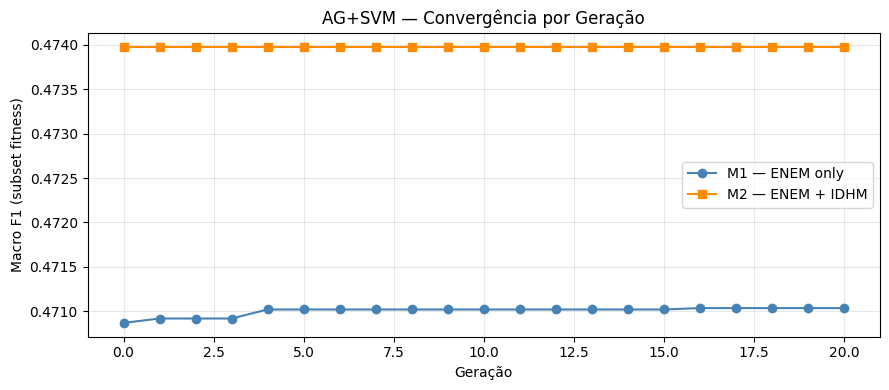

Salvo: fig_ag_convergencia.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(GA_GENS+1), hist_m1, 'o-', color='steelblue',  label='M1 — ENEM only')
ax.plot(range(GA_GENS+1), hist_m2, 's-', color='darkorange', label='M2 — ENEM + IDHM')
ax.set_xlabel('Geração')
ax.set_ylabel('Macro F1 (subset fitness)')
ax.set_title('AG+SVM — Convergência por Geração')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_ag_convergencia.png', dpi=150)
plt.show()
print('Salvo: fig_ag_convergencia.png')

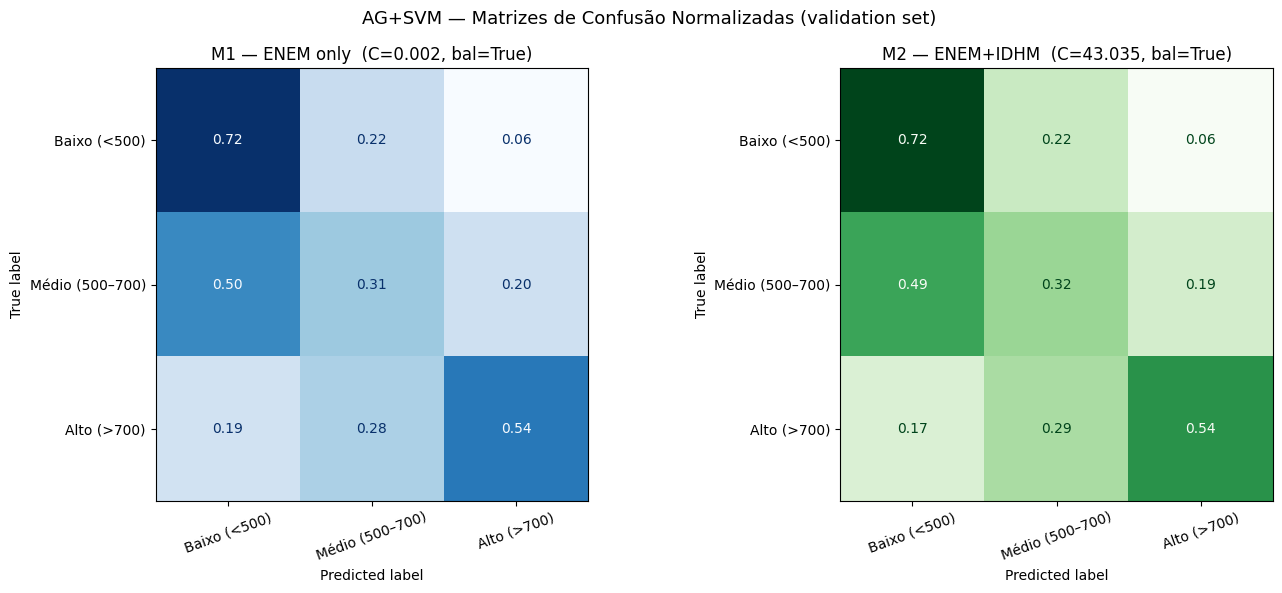

Salvo: fig_ag_svm_cm.png


In [11]:
cm_m1 = confusion_matrix(y_val, yp_m1, normalize='true')
cm_m2 = confusion_matrix(y_val, yp_m2, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, cmap in zip(
    axes,
    [cm_m1, cm_m2],
    [f'M1 — ENEM only  (C={best_C_m1:.3f}, bal={best_bal_m1})',
     f'M2 — ENEM+IDHM  (C={best_C_m2:.3f}, bal={best_bal_m2})'],
    ['Blues', 'Greens']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER)
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('AG+SVM — Matrizes de Confusão Normalizadas (validation set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_ag_svm_cm.png', dpi=150)
plt.show()
print('Salvo: fig_ag_svm_cm.png')

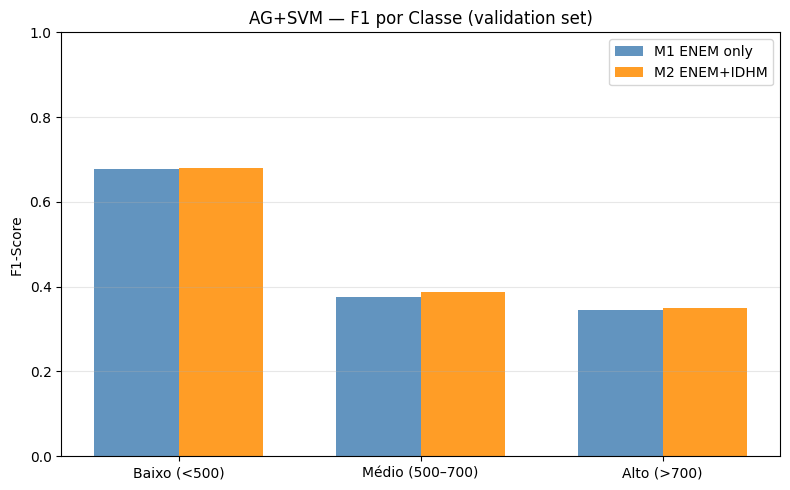

Salvo: fig_ag_svm_f1_classe.png


In [12]:
f1_m1 = f1_score(y_val, yp_m1, average=None, labels=[0, 1, 2])
f1_m2 = f1_score(y_val, yp_m2, average=None, labels=[0, 1, 2])

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1_m1, w, label=f'M1 ENEM only',  color='steelblue',  alpha=0.85)
ax.bar(x + w/2, f1_m2, w, label=f'M2 ENEM+IDHM', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('AG+SVM — F1 por Classe (validation set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_ag_svm_f1_classe.png', dpi=150)
plt.show()
print('Salvo: fig_ag_svm_f1_classe.png')

## Seção 8 — Persistência

In [13]:
joblib.dump(pipe_m1, f'{MODELS_DIR}/ag_svm_enem_only_faixa_mt.pkl')
joblib.dump(pipe_m2, f'{MODELS_DIR}/ag_svm_enem_idhm_faixa_mt.pkl')

joblib.dump({
    'm1': {'C': best_C_m1, 'balanced': best_bal_m1, 'fitness': best_fit_m1, 'history': hist_m1},
    'm2': {'C': best_C_m2, 'balanced': best_bal_m2, 'fitness': best_fit_m2, 'history': hist_m2},
    'val_metrics': {'m1': m1_met, 'm2': m2_met},
}, f'{MODELS_DIR}/ag_svm_results.pkl')

print('Modelos salvos:')
print(f'  data/models/ag_svm_enem_only_faixa_mt.pkl')
print(f'  data/models/ag_svm_enem_idhm_faixa_mt.pkl')
print(f'  data/models/ag_svm_results.pkl')

print('\n=== RESUMO FINAL ===')
print(df_res.to_string(index=False))
print('\n* Test set selado em data/models/test_sets_selados.pkl')

Modelos salvos:
  data/models/ag_svm_enem_only_faixa_mt.pkl
  data/models/ag_svm_enem_idhm_faixa_mt.pkl
  data/models/ag_svm_results.pkl

=== RESUMO FINAL ===
             Modelo       C balanced  Accuracy  Macro F1  Weighted F1
Baseline (majority)       —        —  0.523053  0.228949     0.359257
 AG+SVM — ENEM only  0.0016     True  0.540279  0.466001     0.531306
 AG+SVM — ENEM+IDHM 43.0353     True  0.545278  0.471724     0.537092

* Test set selado em data/models/test_sets_selados.pkl
